#  Motor Vehicle Collisions – Data Cleaning, Exploration & Borough Imputation

This notebook focuses on preparing and analyzing a motor vehicle crash dataset to understand **temporal and borough-level crash trends** and to improve data quality through structured cleaning and machine-learning based imputation.

---

##  Data Loading and Initial Inspection

The dataset is loaded using Pandas and inspected using:
- shape and column information
- data types
- missing values in key geographic fields (Latitude and Longitude)

This initial check helps identify data quality issues and guides the cleaning strategy.

---

In [1]:
import pandas as pd

df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260204.csv")

/tmp/ipykernel_133/884656726.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260204.csv")


In [5]:
df.shape

(2239103, 29)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239103 entries, 0 to 2239102
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       object 
 7   ON STREET NAME                 object 
 8   CROSS STREET NAME              object 
 9   OFF STREET NAME                object 
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CO

In [5]:
df[['LATITUDE','LONGITUDE']].isnull().sum()

LATITUDE     240564
LONGITUDE    240564
dtype: int64



## Date & Time Processing

The following columns are converted into proper datetime formats:

- `CRASH DATE`
- `CRASH TIME`

This enables:
- reliable time-based filtering
- extraction of temporal features such as year
- consistent trend analysis

---

In [6]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce').dt.time


In [7]:
start_date = '2015-01-01'
end_date = '2025-12-31'

df_filtered = df[
    (df['CRASH DATE'] >= start_date) & 
    (df['CRASH DATE'] <= end_date)
].copy()

df_filtered['YEAR'] = df_filtered['CRASH DATE'].dt.year



In [8]:
df_filtered['YEAR'].value_counts().sort_index()

YEAR
2015    217708
2016    229832
2017    231007
2018    231564
2019    211486
2020    112917
2021    110557
2022    103887
2023     96607
2024     91315
2025     85481
Name: count, dtype: int64

In [9]:
borough_year_pivot = (
    df_filtered
    .pivot_table(
        index='BOROUGH',
        columns='YEAR',
        aggfunc='size',
        fill_value=0
    )
)

borough_year_pivot

YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
BOROUGH,,,,,,,,,,,
BRONX,21258,21660,21397,23060,22437,14306,13389,12285,10507,10033,10243
BROOKLYN,50851,47464,44915,47313,44479,25472,25173,23369,22890,22785,24281
MANHATTAN,42528,36077,31774,31412,26593,10855,11432,11988,11822,11903,13224
QUEENS,42493,41395,38627,41278,39865,20667,19564,18427,17786,17812,17934
STATEN ISLAND,6344,6709,6241,6171,3650,2388,2665,2718,2724,2697,2776


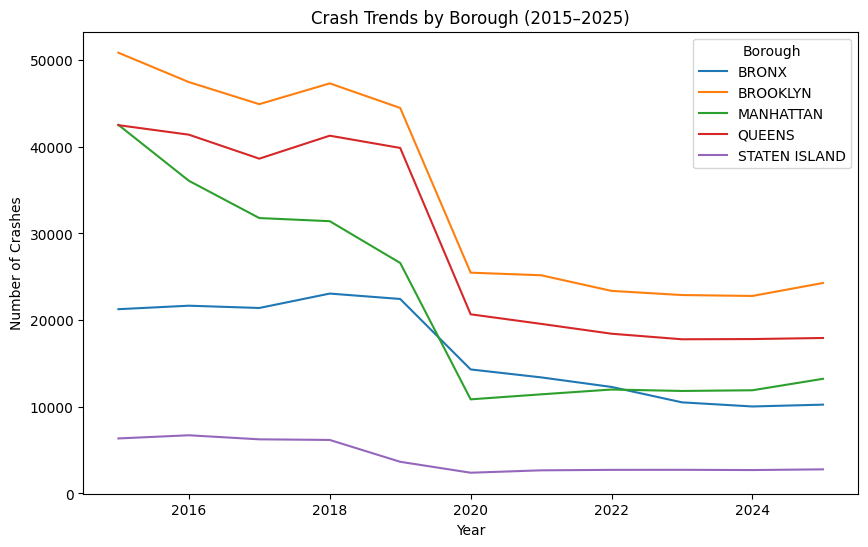

In [10]:
import matplotlib.pyplot as plt

crash_by_borough_year = (
    df_filtered
    .groupby(['YEAR', 'BOROUGH'])
    .size()
    .unstack()
)

ax = crash_by_borough_year.plot(figsize=(10,6))

ax.set_xlabel("Year")
ax.set_ylabel("Number of Crashes")
ax.set_title("Crash Trends by Borough (2015–2025)")

plt.legend(title="Borough")
plt.show()



---

## Removal of Invalid and Non-informative Records

A filtering condition is applied to remove records where:

- borough, zip code, and street information are missing
- geographic coordinates are missing or equal to zero
- location information is unavailable

This step removes rows that contain insufficient information for spatial and analytical use.

The dataset shape is compared before and after removal to validate the impact of this cleaning step.

---

In [11]:
condition = (
    (df_filtered['BOROUGH'].isnull()) &
    (df_filtered['ZIP CODE'].isnull()) &
    ((df_filtered['LATITUDE'].isnull()) | (df['LATITUDE'] == 0)) &
    ((df_filtered['LONGITUDE'].isnull()) | (df['LONGITUDE'] == 0)) &
    (df_filtered['LOCATION'].isnull()) &
    (df_filtered['ON STREET NAME'].isnull()) &
    (df_filtered['CROSS STREET NAME'].isnull()) &
    (df_filtered['OFF STREET NAME'].isnull()) &
    ((df_filtered['NUMBER OF PERSONS INJURED'].isnull()) | (df['NUMBER OF PERSONS INJURED'] == 0))
)

condition.sum()

np.int64(8991)

In [12]:

condition.sum()

print("Shape BEFORE:", df_filtered.shape)
print("Rows to remove:", condition.sum())

df_filtered = df_filtered.loc[~condition].copy()
df_filtered.reset_index(drop=True, inplace=True)

print("Shape AFTER:", df_filtered.shape)

Shape BEFORE: (1722361, 30)
Rows to remove: 8991
Shape AFTER: (1713370, 30)


In [13]:
df_filtered['YEAR'].value_counts().sort_index()

YEAR
2015    211176
2016    227849
2017    230792
2018    231308
2019    211483
2020    112917
2021    110556
2022    103886
2023     96607
2024     91315
2025     85481
Name: count, dtype: int64

In [14]:
# Filter 2015–2025
df_2015_2025 = df_filtered[
    (df_filtered['YEAR'] >= 2015) &
    (df_filtered['YEAR'] <= 2025)
]

# Create pivot table (BOROUGH as rows, YEAR as columns)
borough_year_pivot = (
    df_2015_2025
    .pivot_table(
        index='BOROUGH',
        columns='YEAR',
        aggfunc='size',
        fill_value=0
    )
    .sort_index()
)

borough_year_pivot

YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
BOROUGH,,,,,,,,,,,
BRONX,21258,21660,21397,23060,22437,14306,13389,12285,10507,10033,10243
BROOKLYN,50851,47464,44915,47313,44479,25472,25173,23369,22890,22785,24281
MANHATTAN,42528,36077,31774,31412,26593,10855,11432,11988,11822,11903,13224
QUEENS,42493,41395,38627,41278,39865,20667,19564,18427,17786,17812,17934
STATEN ISLAND,6344,6709,6241,6171,3650,2388,2665,2718,2724,2697,2776


In [15]:
df_2015_2025.shape

(1713370, 30)

In [16]:
df_filtered.isnull().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           553264
ZIP CODE                          553542
LATITUDE                          151305
LONGITUDE                         151305
LOCATION                          151305
ON STREET NAME                    404359
CROSS STREET NAME                 770261
OFF STREET NAME                  1333199
NUMBER OF PERSONS INJURED             17
NUMBER OF PERSONS KILLED              30
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7212
CONTRIBUTING FACTOR VEHICLE 2     298320
CONTRIBUTING FACTOR VEHICLE 3    1585844
CONTRIBUTING FACTOR VEHICLE 4    1683375
CONTRIBUTING FACTOR VEHICLE 5    1704947
COLLISION_ID                           0
VEHICLE TYPE COD

In [17]:
df_filtered[[ 'LOCATION']].isnull().sum()

LOCATION    151305
dtype: int64

In [18]:
print("Shape before cleaning:", df_filtered.shape)

df_filtered = df_filtered.dropna(subset=['LONGITUDE', 'LOCATION'])

print("Shape after cleaning:", df_filtered.shape)

Shape before cleaning: (1713370, 30)
Shape after cleaning: (1562065, 30)


In [19]:
df_filtered[[ 'LOCATION']].isnull().sum()

LOCATION    0
dtype: int64

In [20]:
df_filtered.isnull().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           439752
ZIP CODE                          440004
LATITUDE                               0
LONGITUDE                              0
LOCATION                               0
ON STREET NAME                    386873
CROSS STREET NAME                 712634
OFF STREET NAME                  1197051
NUMBER OF PERSONS INJURED             16
NUMBER OF PERSONS KILLED              28
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       6749
CONTRIBUTING FACTOR VEHICLE 2     275855
CONTRIBUTING FACTOR VEHICLE 3    1446413
CONTRIBUTING FACTOR VEHICLE 4    1534643
CONTRIBUTING FACTOR VEHICLE 5    1554283
COLLISION_ID                           0
VEHICLE TYPE COD

In [21]:
train_df = df_filtered[df_filtered["BOROUGH"].notna()]
test_df = df_filtered[df_filtered["BOROUGH"].isna()]


##  Handling Missing Borough Values Using Machine Learning

To recover missing borough information, a machine learning approach is applied.

Records are split into:
- a training set (rows with known boroughs)
- a test set (rows with missing boroughs)

Only geographic features are used:
- **Latitude**
- **Longitude**

A K-Nearest Neighbors (KNN) classifier is trained to learn spatial patterns and predict the borough for records with missing values.

The model is evaluated using a validation split and accuracy score to ensure reasonable prediction performance.

This approach allows:
- recovery of missing categorical information
- preservation of otherwise valuable crash records

---


In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

# Check missing BEFORE
print("Missing BOROUGH BEFORE:", df_filtered["BOROUGH"].isna().sum())

# Work on a copy to avoid warnings
df_ml = df_filtered.copy()

# Drop rows with missing coordinates
df_ml = df_ml.dropna(subset=["LATITUDE", "LONGITUDE"])

# Separate known / unknown borough
train_df = df_ml[df_ml["BOROUGH"].notna()].copy()
test_df = df_ml[df_ml["BOROUGH"].isna()].copy()

# Encode borough
le = LabelEncoder()
train_df["borough_encoded"] = le.fit_transform(train_df["BOROUGH"])

# Train model
X_train = train_df[["LATITUDE", "LONGITUDE"]]
y_train = train_df["borough_encoded"]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Predict missing borough
if len(test_df) > 0:
    X_test = test_df[["LATITUDE", "LONGITUDE"]]
    predicted = model.predict(X_test)

    test_df["BOROUGH"] = le.inverse_transform(predicted)

    # Update original df_filtered
    df_filtered.update(test_df)

# Check missing AFTER
print("Missing BOROUGH AFTER:", df_filtered["BOROUGH"].isna().sum())

Missing BOROUGH BEFORE: 439752
Missing BOROUGH AFTER: 0


/var/folders/wr/mm1996jd4p9grx5zzl61s8h40000gn/T/ipykernel_1905/1397754846.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2023 2021 2021 ... 2021 2021 2021]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df_filtered.update(test_df)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = train_df[["LATITUDE", "LONGITUDE"]]
y = train_df["borough_encoded"]

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_tr, y_tr)
val_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))

Validation Accuracy: 0.9951216904345037


---

##  Duplicate Check

A final duplicate record check is performed to ensure no repeated rows remain in the cleaned dataset.

---


In [24]:
print("Total duplicate rows:", df_filtered.duplicated().sum())

Total duplicate rows: 0


---
## Removing the unnecessary column

---

In [25]:
print("Shape BEFORE:", df_filtered.shape)

Shape BEFORE: (1562065, 30)


In [26]:
columns_to_drop = [
    "ON STREET NAME",
    "OFF STREET NAME",
    "CROSS STREET NAME",
    "CONTRIBUTING FACTOR VEHICLE 4",
    "CONTRIBUTING FACTOR VEHICLE 5",
    "COLLISION_ID",  # use exact column name from your dataset
    "VEHICLE TYPE CODE 4",
    "VEHICLE TYPE CODE 5"
]

crash_data = df_filtered.drop(columns=columns_to_drop, errors='ignore').copy()

In [27]:
print("Shape AFTER:", crash_data.shape)

Shape AFTER: (1562065, 22)


-----
----


#  Data Cleaning: Automated_Traffic_Volume_Counts_20260221

##  Overview
This section focuses on cleaning and preparing the dataset **Automated_Traffic_Volume_Counts_20260221** for further analysis and feature engineering. The objective is to ensure data consistency, accuracy, and readiness for modeling.

---

##  Data Cleaning Steps Performed

###  Data Loading
- Imported the dataset using `pandas`
- Inspected shape, columns, and data types
- Checked for mixed data types and memory warnings

### Handling Data Types
- Verified numeric columns (`Yr`, `M`, `D`, `HH`, etc.)
- Converted year, month, and day columns into a proper datetime format
- Created a new `DATE` column using:
  - `Yr` (Year)
  - `M` (Month)
  - `D` (Day)

### Date Filtering
- Filtered records between:
  - **01 January 2015**
  - **31 December 2025**
- Ensured the dataset contains only relevant time-range data

###  Removing Unnecessary Columns
- Dropped irrelevant or redundant columns (e.g., identifiers or geometry fields if not required for analysis)
- Reduced dataset dimensionality for efficiency

###  Missing Value Inspection
- Checked for null values
- Verified completeness of critical fields

###  Data Validation
- Confirmed final date range
- Verified year distribution
- Checked dataset shape after filtering


In [28]:
au  = pd.read_csv("Automated_Traffic_Volume_Counts_20260221.csv")

/var/folders/wr/mm1996jd4p9grx5zzl61s8h40000gn/T/ipykernel_1905/3727609569.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  au  = pd.read_csv("Automated_Traffic_Volume_Counts_20260221.csv")


In [29]:
au.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838386 entries, 0 to 1838385
Data columns (total 14 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   RequestID  int64 
 1   Boro       object
 2   Yr         int64 
 3   M          int64 
 4   D          int64 
 5   HH         int64 
 6   MM         int64 
 7   Vol        object
 8   SegmentID  int64 
 9   WktGeom    object
 10  street     object
 11  fromSt     object
 12  toSt       object
 13  Direction  object
dtypes: int64(7), object(7)
memory usage: 196.4+ MB


In [30]:
au['Yr'].nunique()

21

In [31]:
au['Yr'].value_counts().sort_index()

Yr
2000      1904
2006       664
2007      8130
2008     32482
2009    122851
2010    132016
2011    120249
2012    128222
2013    128762
2014    130754
2015    124428
2016    129617
2017    123901
2018     98961
2019    115730
2020     40224
2021     85810
2022     78652
2023     85106
2024     95203
2025     54720
Name: count, dtype: int64

In [36]:
au["DATE"] = pd.to_datetime(
    au[["Yr", "M", "D"]]
    .rename(columns={"Yr": "year", "M": "month", "D": "day"})
)
au["DATE"].head()

0   2016-05-08
1   2016-05-08
2   2016-05-08
3   2016-05-08
4   2016-05-08
Name: DATE, dtype: datetime64[ns]

In [37]:
start_date = pd.Timestamp(2015, 1, 1)
end_date = pd.Timestamp(2025, 12, 31)

au_filtered = au[
    (au["DATE"] >= start_date) &
    (au["DATE"] <= end_date)
]

In [38]:
au_filtered["DATE"].min()

Timestamp('2015-01-04 00:00:00')

In [39]:
au_filtered["DATE"].max()

Timestamp('2025-12-11 00:00:00')

----
----


#  Feature Engineering

## Overview
After completing the data cleaning phase, feature engineering was performed to enhance the predictive capability of the dataset. The goal was to transform raw variables into meaningful features that better represent traffic patterns and temporal behavior.

Feature engineering improves model performance by extracting structured insights from date, time, and categorical variables.


In [40]:
crash_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1562065 entries, 2 to 1713369
Data columns (total 22 columns):
 #   Column                         Non-Null Count    Dtype         
---  ------                         --------------    -----         
 0   CRASH DATE                     1562065 non-null  datetime64[ns]
 1   CRASH TIME                     1562065 non-null  object        
 2   BOROUGH                        1562065 non-null  object        
 3   ZIP CODE                       1122061 non-null  object        
 4   LATITUDE                       1562065 non-null  float64       
 5   LONGITUDE                      1562065 non-null  float64       
 6   LOCATION                       1562065 non-null  object        
 7   NUMBER OF PERSONS INJURED      1562049 non-null  float64       
 8   NUMBER OF PERSONS KILLED       1562037 non-null  float64       
 9   NUMBER OF PEDESTRIANS INJURED  1562065 non-null  int64         
 10  NUMBER OF PEDESTRIANS KILLED   1562065 non-null  int64     

In [41]:
au.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1838386 entries, 0 to 1838385
Data columns (total 15 columns):
 #   Column     Dtype         
---  ------     -----         
 0   RequestID  int64         
 1   Boro       object        
 2   Yr         int64         
 3   M          int64         
 4   D          int64         
 5   HH         int64         
 6   MM         int64         
 7   Vol        object        
 8   SegmentID  int64         
 9   WktGeom    object        
 10  street     object        
 11  fromSt     object        
 12  toSt       object        
 13  Direction  object        
 14  DATE       datetime64[ns]
dtypes: datetime64[ns](1), int64(7), object(7)
memory usage: 210.4+ MB


## Exploratory Data Analysis (EDA)

In this section, we explore the relationship between traffic volume and motor vehicle crashes using the cleaned datasets.

Two datasets are used:

- **crash_data** – Contains information about motor vehicle crashes such as borough, time, injuries, and crash counts.
- **au_filtered** – Contains automated traffic volume counts.

The goal of this analysis is to understand how traffic patterns influence crash occurrences.

The following visualizations are created:

1. Injury Rate per Borough
2. Traffic Volume vs Number of Crashes
3. Average Crash Count by Traffic Category
4. Crash Rate by Borough
5. Heatmap of Crash Frequency by Hour

These visualizations help identify patterns in crash occurrences and understand whether higher traffic volumes lead to more crashes.

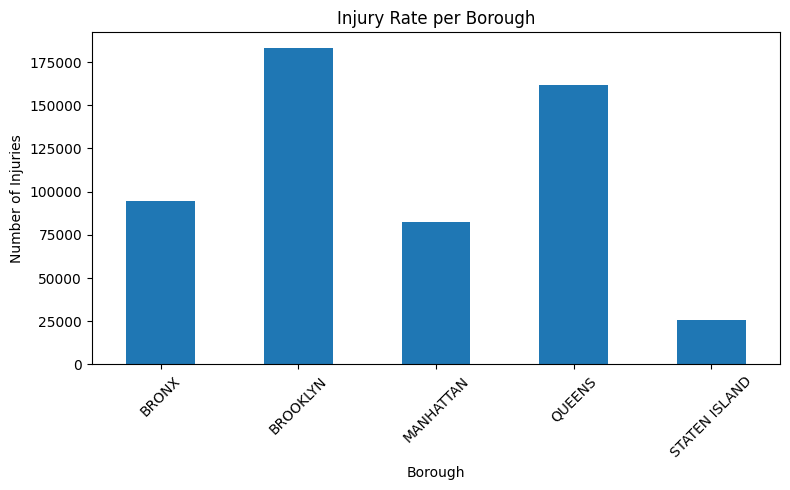

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate total injuries per borough
injury_borough = crash_data.groupby('BOROUGH')['NUMBER OF PERSONS INJURED'].sum()

# Plot
plt.figure(figsize=(8,5))
injury_borough.plot(kind='bar')

plt.title('Injury Rate per Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Injuries')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Injury Rate per Borough

This visualization shows the average number of injured persons in crashes
across different boroughs. It helps identify which boroughs experience
more severe accidents.

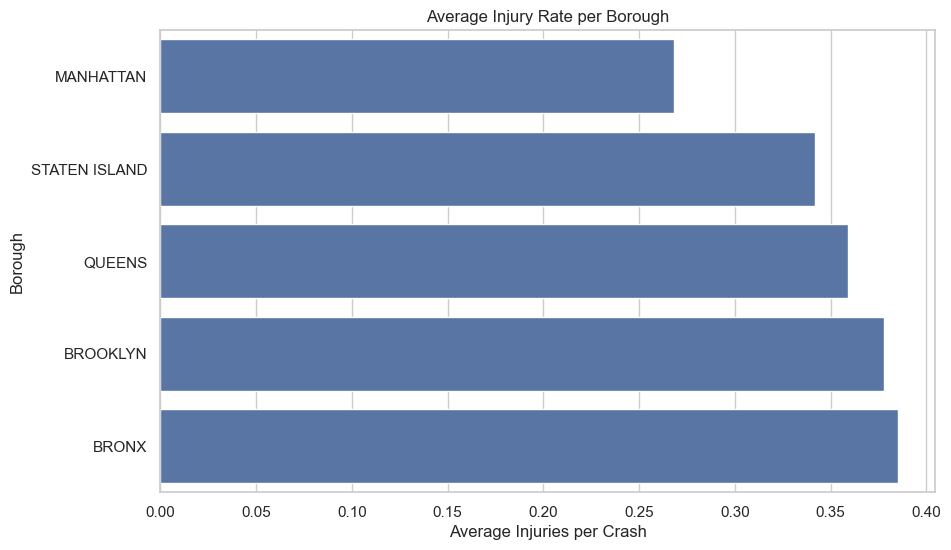

In [75]:
injury_rate = df_filtered.groupby("BOROUGH")["NUMBER OF PERSONS INJURED"].mean().sort_values()

plt.figure()

sns.barplot(
    x=injury_rate.values,
    y=injury_rate.index
)

plt.title("Average Injury Rate per Borough")
plt.xlabel("Average Injuries per Crash")
plt.ylabel("Borough")

plt.show()

### Traffic Volume vs Number of Crashes

This analysis compares yearly traffic volume with the total number of crashes.
It helps determine whether higher traffic volumes lead to increased crash counts.

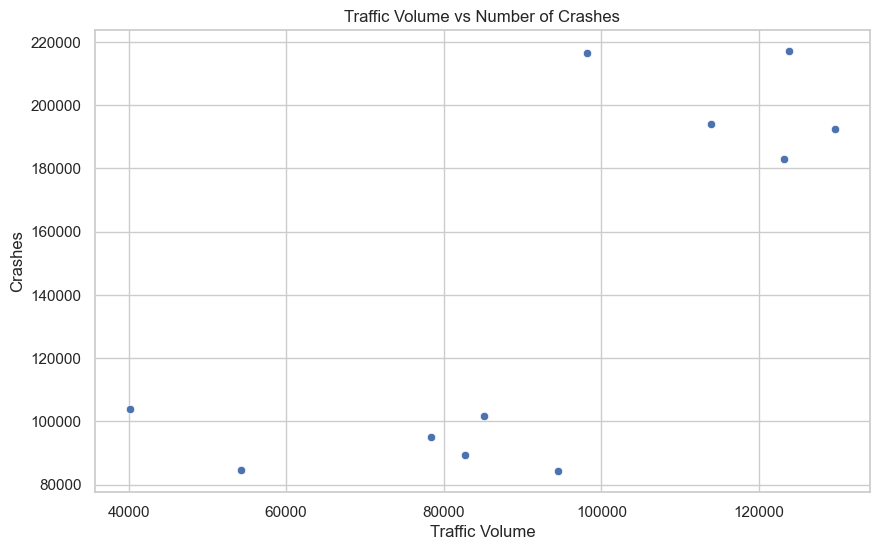

In [76]:
# total crashes per year
crashes_per_year = df_filtered.groupby("YEAR").size()

# traffic volume per year
traffic_per_year = au.groupby("Yr")["Vol"].count()

# combine datasets
traffic_crash_df = pd.DataFrame({
    "Crashes": crashes_per_year,
    "Traffic Volume": traffic_per_year
}).dropna()

plt.figure()

sns.scatterplot(
    data=traffic_crash_df,
    x="Traffic Volume",
    y="Crashes"
)

plt.title("Traffic Volume vs Number of Crashes")

plt.show()

### Average Crash Count by Traffic Category

Traffic volume is categorized into three levels:

- Low Traffic
- Medium Traffic
- High Traffic

This allows us to observe how crash frequency varies with traffic density.

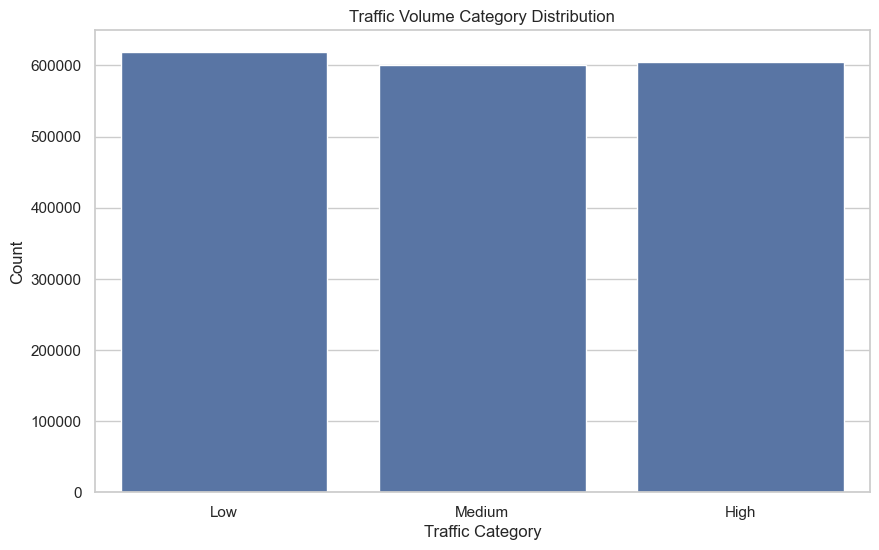

In [77]:
# convert traffic volume to numeric
au["Vol"] = pd.to_numeric(au["Vol"], errors="coerce")

# create categories
au["Traffic_Category"] = pd.qcut(
    au["Vol"],
    q=3,
    labels=["Low", "Medium", "High"]
)

traffic_counts = au["Traffic_Category"].value_counts()

plt.figure()

sns.barplot(
    x=traffic_counts.index,
    y=traffic_counts.values
)

plt.title("Traffic Volume Category Distribution")
plt.xlabel("Traffic Category")
plt.ylabel("Count")

plt.show()

### Crash Rate by Borough

This chart shows the total number of crashes in each borough,
helping identify areas with the highest crash frequency.

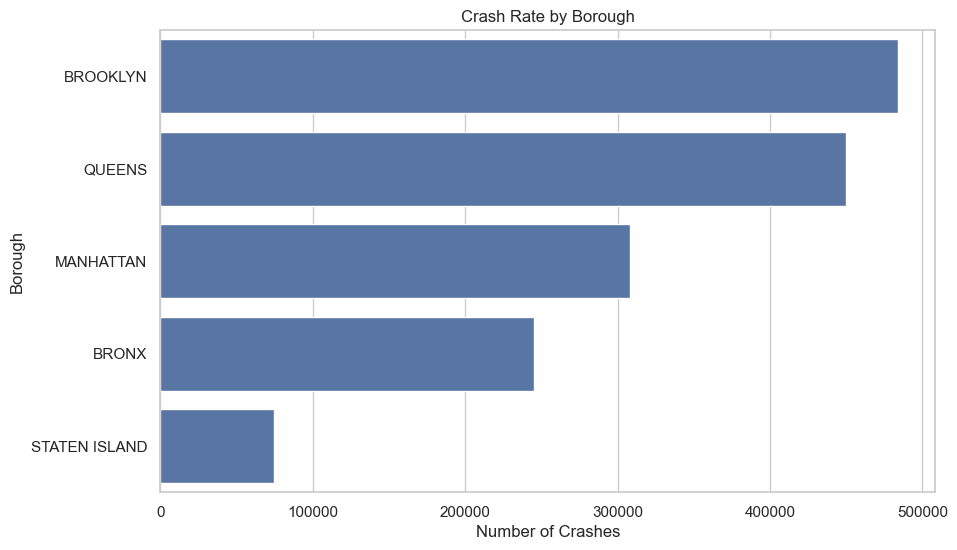

In [78]:
borough_crashes = df_filtered["BOROUGH"].value_counts()

plt.figure()

sns.barplot(
    x=borough_crashes.values,
    y=borough_crashes.index
)

plt.title("Crash Rate by Borough")
plt.xlabel("Number of Crashes")
plt.ylabel("Borough")

plt.show()

### Heatmap of Crash Frequency by Hour

This heatmap visualizes crash frequency across hours of the day and boroughs.
It helps identify peak hours for traffic accidents.

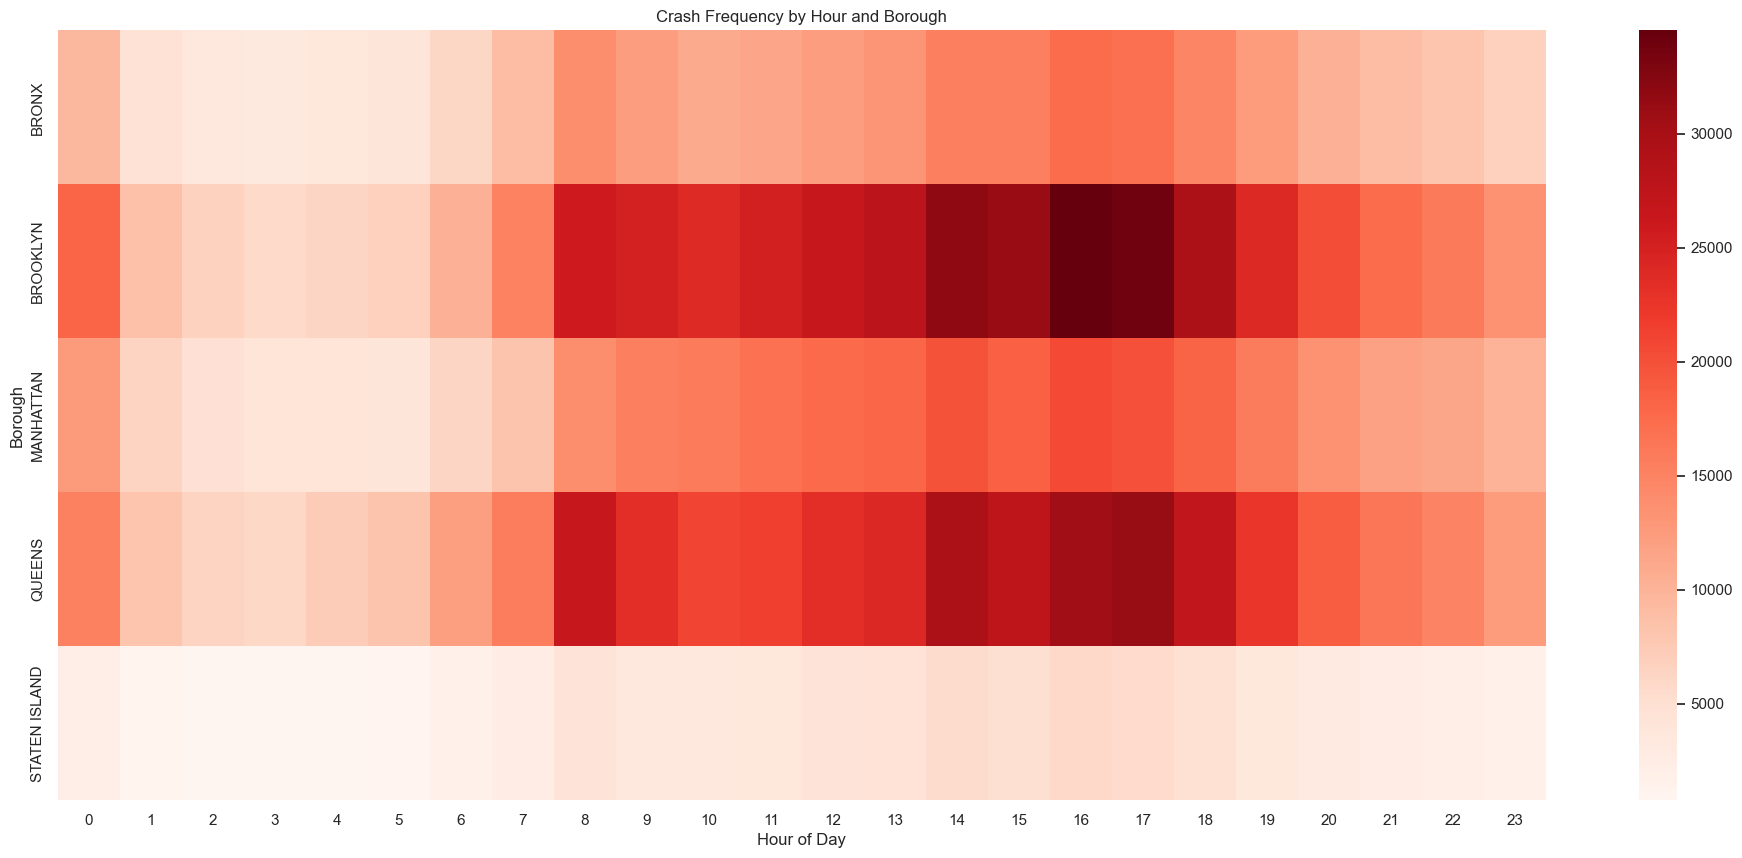

In [83]:
# Extract hour safely
df_filtered["HOUR"] = df_filtered["CRASH TIME"].astype(str).str.split(":").str[0]
df_filtered["HOUR"] = pd.to_numeric(df_filtered["HOUR"], errors="coerce")

# Create heatmap table
heatmap_data = pd.crosstab(
    df_filtered["BOROUGH"],
    df_filtered["HOUR"]
)

# Plot heatmap
plt.figure(figsize=(24,10))

sns.heatmap(
    heatmap_data,
    cmap="Reds"
)

plt.title("Crash Frequency by Hour and Borough")
plt.xlabel("Hour of Day")
plt.ylabel("Borough")

plt.show()